# XGBoost from Scratch

This notebook builds **XGBoost (eXtreme Gradient Boosting)** from first principles
using only NumPy. For every step we first write the **mathematics** in a markdown
cell, then implement that exact step in the **code cell** that follows, explaining
the reasoning as we go.

The plan:

1. The regularized learning objective.
2. Additive (stage-wise) training.
3. The second-order Taylor approximation that gives XGBoost its name.
4. The optimal leaf weight and the *structure score*.
5. The split-finding *gain* used to grow each tree.
6. Loss functions: gradients $g_i$ and hessians $h_i$.
7. A single regression tree that consumes $g$ and $h$.
8. The boosting loop that stacks the trees.
9. Demos on regression and classification, checked against reference `xgboost`.

> Notation: $x_i \in \mathbb{R}^m$ is the feature vector of example $i$, $y_i$ its
> label, and $\hat{y}_i$ the model's prediction.

## 1. The regularized objective

XGBoost is an **additive ensemble of $K$ regression trees**. Each tree $f_k$ lives
in the space $\mathcal{F}$ of trees, and the prediction is the sum of all of them:

$$
\hat{y}_i \;=\; \sum_{k=1}^{K} f_k(x_i), \qquad f_k \in \mathcal{F}.
$$

A tree $f$ is defined by a *structure* $q$ that maps a point to a leaf index, and a
vector of *leaf weights* $w$. So $f(x) = w_{q(x)}$.

We do **not** just minimize the training loss; we add a complexity penalty so the
trees stay simple. The objective is

$$
\mathcal{L} \;=\; \underbrace{\sum_{i=1}^{n} l\big(y_i, \hat{y}_i\big)}_{\text{how well we fit}}
\;+\; \underbrace{\sum_{k=1}^{K} \Omega(f_k)}_{\text{how complex we are}},
\qquad
\Omega(f) = \gamma T + \tfrac{1}{2}\lambda \lVert w \rVert^2 .
$$

Here $T$ is the number of leaves in the tree, $\gamma$ penalizes *having leaves at
all* (it controls pruning), and $\lambda$ is L2 regularization on the leaf weights.
$l$ is any differentiable convex loss (squared error, logistic, ...).

**Reasoning:** trees are flexible enough to memorize the data. The $\Omega$ term is
what keeps each tree shallow and its predictions small, which is the whole reason
XGBoost generalizes well. We will see $\gamma$ and $\lambda$ reappear in concrete
formulas below — they are not afterthoughts, they fall directly out of the math.

## 2. Additive training

We cannot optimize over all $K$ trees at once (the space of trees is discrete and
enormous). Instead we train **greedily, one tree at a time** — this is *boosting*.

Let $\hat{y}_i^{(t)}$ be the prediction after $t$ trees. At round $t$ we keep the
first $t-1$ trees fixed and add a new tree $f_t$:

$$
\hat{y}_i^{(t)} \;=\; \hat{y}_i^{(t-1)} \;+\; f_t(x_i).
$$

Substituting into the objective, the only thing we get to choose at round $t$ is
$f_t$, so the objective to minimize *this round* is

$$
\mathcal{L}^{(t)} \;=\; \sum_{i=1}^{n} l\Big(y_i,\; \hat{y}_i^{(t-1)} + f_t(x_i)\Big)
\;+\; \Omega(f_t) \;+\; \text{const}.
$$

**Reasoning:** each new tree is trained to correct the residual error left by all
the trees before it. The terms $\Omega(f_1),\dots,\Omega(f_{t-1})$ are constants now
(those trees are frozen), so they drop out of the optimization for $f_t$.

## 3. Second-order Taylor approximation

The loss $l$ can be anything, so $\mathcal{L}^{(t)}$ has no general closed form. The
key XGBoost trick is to **Taylor-expand the loss to second order** around the current
prediction $\hat{y}_i^{(t-1)}$, treating $f_t(x_i)$ as the small step:

$$
l\Big(y_i,\; \hat{y}_i^{(t-1)} + f_t(x_i)\Big)
\;\approx\;
l\big(y_i, \hat{y}_i^{(t-1)}\big)
+ g_i\, f_t(x_i)
+ \tfrac{1}{2} h_i\, f_t(x_i)^2 ,
$$

where the **gradient** and **hessian** of the loss w.r.t. the prediction are

$$
g_i = \frac{\partial\, l(y_i, \hat{y})}{\partial \hat{y}}\bigg|_{\hat{y}=\hat{y}_i^{(t-1)}},
\qquad
h_i = \frac{\partial^2\, l(y_i, \hat{y})}{\partial \hat{y}^2}\bigg|_{\hat{y}=\hat{y}_i^{(t-1)}}.
$$

Dropping the constant $l(y_i, \hat{y}_i^{(t-1)})$ (it does not depend on $f_t$), the
**simplified objective** is

$$
\tilde{\mathcal{L}}^{(t)} \;=\; \sum_{i=1}^{n}\Big[ g_i\, f_t(x_i) + \tfrac{1}{2} h_i\, f_t(x_i)^2 \Big] + \Omega(f_t).
$$

**Reasoning:** this is the move that makes the algorithm "extreme." Whatever the loss
is, the only information a new tree needs about it is the per-example pair
$(g_i, h_i)$. The tree-growing code below is therefore completely loss-agnostic — swap
the loss and only $g$ and $h$ change. (Ordinary gradient boosting uses only $g_i$;
using $h_i$ too is a Newton step and converges faster.)

## 4. Optimal leaf weight and the structure score

Now use the tree structure. Let $I_j = \{\, i : q(x_i) = j \,\}$ be the set of
training examples that land in leaf $j$. Since every example in leaf $j$ gets the
same output $w_j$, we can **group the sum by leaf**. Define the per-leaf gradient and
hessian sums

$$
G_j = \sum_{i \in I_j} g_i, \qquad H_j = \sum_{i \in I_j} h_i.
$$

Plugging $f_t(x_i)=w_{q(x_i)}$ and $\Omega = \gamma T + \tfrac12\lambda\sum_j w_j^2$
into $\tilde{\mathcal{L}}^{(t)}$ and regrouping over the $T$ leaves:

$$
\tilde{\mathcal{L}}^{(t)}
= \sum_{j=1}^{T}\Big[ G_j\, w_j + \tfrac{1}{2}\big(H_j + \lambda\big) w_j^2 \Big] + \gamma T.
$$

For a **fixed tree structure**, this is just a sum of independent quadratics in each
$w_j$. Minimize by setting the derivative to zero,
$G_j + (H_j+\lambda)w_j = 0$, giving the **optimal leaf weight**

$$
\boxed{\,w_j^{*} = -\dfrac{G_j}{H_j + \lambda}\,}.
$$

Substituting $w_j^*$ back gives the **structure score** — how good a given tree shape
is:

$$
\tilde{\mathcal{L}}^{(t)}(q) = -\frac{1}{2}\sum_{j=1}^{T} \frac{G_j^2}{H_j + \lambda} + \gamma T.
$$

**Reasoning:** the leaf value is *not* the mean residual (that would be plain GBM with
squared error). It is a hessian-weighted, L2-regularized version. $\lambda$ in the
denominator shrinks leaf weights toward zero — exactly the regularization we wrote in
step 1, now made concrete. A lower structure score means a better tree.

## 5. The split gain

The structure score scores a *whole* tree, but we cannot enumerate all tree shapes.
So we grow the tree **greedily**: start from a single leaf and repeatedly pick the
split that improves the score the most.

Consider a leaf with instance set $I$ that we split into a left child $I_L$ and right
child $I_R$ ($I = I_L \cup I_R$). Using the structure-score formula, the reduction in
objective from this one split (the **gain**) is

$$
\text{Gain} = \frac{1}{2}\left[
\frac{G_L^2}{H_L + \lambda} + \frac{G_R^2}{H_R + \lambda} - \frac{(G_L+G_R)^2}{H_L+H_R+\lambda}
\right] - \gamma .
$$

The three terms are: score of the new left leaf, score of the new right leaf, minus
the score of the original (un-split) leaf. The $-\gamma$ is the cost of adding one
extra leaf.

**Reasoning:** we evaluate this gain for every feature and every candidate threshold
and keep the best. A split is only worth making if $\text{Gain} > 0$; because of the
$-\gamma$ term, weak splits produce *negative* gain and are rejected — this is
built-in pre-pruning. The first two terms reward splits that cleanly separate examples
with different gradients.

## 6. Loss functions: gradients and hessians

Everything above needs only $g_i$ and $h_i$. Let us derive them for the two losses we
will use. Throughout, $\hat{y}$ is the **raw model output** (the *margin* / logit).

**Squared error (regression).** With $l = \tfrac{1}{2}(y - \hat{y})^2$:

$$
g_i = \frac{\partial l}{\partial \hat{y}} = \hat{y}_i - y_i,
\qquad
h_i = \frac{\partial^2 l}{\partial \hat{y}^2} = 1.
$$

**Logistic / binary cross-entropy (classification).** The model outputs a logit
$\hat{y}$; the predicted probability is $p = \sigma(\hat{y}) = \frac{1}{1+e^{-\hat{y}}}$,
and $l = -\big[y\ln p + (1-y)\ln(1-p)\big]$. Using $\sigma' = \sigma(1-\sigma)$:

$$
g_i = p_i - y_i,
\qquad
h_i = p_i\,(1 - p_i).
$$

**Reasoning:** for squared error the hessian is constant, so the Newton step reduces
to ordinary gradient descent — XGBoost on regression behaves like classic gradient
boosting. For logistic loss the hessian $p(1-p)$ is largest near $p=0.5$ (uncertain
points) and tiny near $0$ or $1$ (confident points), so confident points get small
leaf updates automatically. Both gradients have the clean form *prediction minus
target*.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, accuracy_score, roc_auc_score

rng = np.random.RandomState(42)
np.set_printoptions(precision=4, suppress=True)

In [2]:
class SquaredErrorLoss:
    """Regression loss l = 1/2 (y - yhat)^2.  yhat is the raw prediction."""

    name = "reg:squarederror"

    def gradient(self, y, pred):
        # dl/dyhat = yhat - y
        return pred - y

    def hessian(self, y, pred):
        # d2l/dyhat2 = 1  (constant)
        return np.ones_like(y, dtype=float)

    def loss(self, y, pred):
        return 0.5 * np.mean((y - pred) ** 2)

    def init_raw(self, y):
        # Best constant prediction under MSE is the mean.
        return float(np.mean(y))

    def output(self, raw):
        # The raw margin already is the prediction for regression.
        return raw


class LogisticLoss:
    """Binary log-loss. The model outputs a logit; probability = sigmoid(logit)."""

    name = "binary:logistic"

    @staticmethod
    def _sigmoid(x):
        return 1.0 / (1.0 + np.exp(-x))

    def gradient(self, y, pred):
        p = self._sigmoid(pred)
        return p - y                      # g = p - y

    def hessian(self, y, pred):
        p = self._sigmoid(pred)
        return np.maximum(p * (1.0 - p), 1e-6)   # h = p(1-p), floored for stability

    def loss(self, y, pred):
        p = np.clip(self._sigmoid(pred), 1e-15, 1 - 1e-15)
        return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))

    def init_raw(self, y):
        # Best constant logit is log(odds) of the base rate.
        p = np.clip(np.mean(y), 1e-6, 1 - 1e-6)
        return float(np.log(p / (1 - p)))

    def output(self, raw):
        # Convert logit margin to probability.
        return self._sigmoid(raw)

## 7. A single tree that consumes $g$ and $h$

A node stores either a **split** (feature index + threshold + children) or a **leaf**
(a single weight $w_j^*$). We grow it greedily using the gain from step 5 and assign
leaf weights using $w_j^* = -G_j/(H_j+\lambda)$ from step 4.

Two extra knobs that real XGBoost uses, included here:

- **`max_depth`** — hard cap on tree depth.
- **`min_child_weight`** — minimum sum of hessians $H$ allowed in a child. A leaf with
  little hessian mass has an unreliable weight (small denominator), so we refuse such
  splits.

**Reasoning:** the tree never sees $y$ directly — it only sees the gradients and
hessians handed to it by the boosting loop. That is the clean separation the Taylor
expansion bought us: the loss lives entirely in $g$ and $h$.

In [3]:
class _Node:
    """A node is either a split (feature/threshold/left/right) or a leaf (weight)."""
    __slots__ = ("is_leaf", "weight", "feature", "threshold", "left", "right")

    def __init__(self):
        self.is_leaf = False
        self.weight = None
        self.feature = None
        self.threshold = None
        self.left = None
        self.right = None


class XGBoostTree:
    def __init__(self, max_depth=3, min_child_weight=1.0, reg_lambda=1.0, gamma=0.0):
        self.max_depth = max_depth
        self.min_child_weight = min_child_weight
        self.reg_lambda = reg_lambda
        self.gamma = gamma
        self.root = None

    # --- step 4: optimal leaf weight  w* = -G / (H + lambda) ----------------
    def _leaf_weight(self, G, H):
        return -G / (H + self.reg_lambda)

    # --- step 5: gain of splitting one node into (L, R) --------------------
    def _gain(self, G_l, H_l, G_r, H_r):
        def score(G, H):
            return (G * G) / (H + self.reg_lambda)
        return 0.5 * (score(G_l, H_l) + score(G_r, H_r)
                      - score(G_l + G_r, H_l + H_r)) - self.gamma

    # --- exact greedy split finding ----------------------------------------
    def _best_split(self, X, g, h):
        n, n_features = X.shape
        G_total, H_total = g.sum(), h.sum()
        best = {"gain": 0.0}

        for feat in range(n_features):
            col = X[:, feat]
            order = np.argsort(col, kind="mergesort")
            col_s, g_s, h_s = col[order], g[order], h[order]

            # Sweep left->right; cumulative sums give (G_L, H_L) in O(1) per cut.
            G_l = H_l = 0.0
            for i in range(n - 1):
                G_l += g_s[i]
                H_l += h_s[i]
                if col_s[i] == col_s[i + 1]:
                    continue  # cannot split between two equal feature values
                G_r, H_r = G_total - G_l, H_total - H_l
                if H_l < self.min_child_weight or H_r < self.min_child_weight:
                    continue
                gain = self._gain(G_l, H_l, G_r, H_r)
                if gain > best["gain"]:
                    best = {"gain": gain, "feature": feat,
                            "threshold": (col_s[i] + col_s[i + 1]) / 2.0}
        return best if "feature" in best else None

    # --- recursive growth ---------------------------------------------------
    def _build(self, X, g, h, depth):
        node = _Node()
        G, H = g.sum(), h.sum()

        if depth >= self.max_depth:
            node.is_leaf = True
            node.weight = self._leaf_weight(G, H)
            return node

        split = self._best_split(X, g, h)
        if split is None:                     # no positive-gain split -> leaf
            node.is_leaf = True
            node.weight = self._leaf_weight(G, H)
            return node

        mask = X[:, split["feature"]] <= split["threshold"]
        node.feature = split["feature"]
        node.threshold = split["threshold"]
        node.left = self._build(X[mask], g[mask], h[mask], depth + 1)
        node.right = self._build(X[~mask], g[~mask], h[~mask], depth + 1)
        return node

    def fit(self, X, g, h):
        self.root = self._build(X, g, h, depth=0)
        return self

    def _predict_row(self, node, x):
        while not node.is_leaf:
            node = node.left if x[node.feature] <= node.threshold else node.right
        return node.weight

    def predict(self, X):
        return np.array([self._predict_row(self.root, x) for x in X])

## 8. The boosting loop

Now we stack the trees (steps 1–3). Each round we:

1. compute $g_i, h_i$ from the **current** predictions,
2. fit one `XGBoostTree` to those $(g,h)$,
3. update the raw prediction with a **learning rate** (shrinkage) $\eta$:

$$
\hat{y}_i^{(t)} = \hat{y}_i^{(t-1)} + \eta\, f_t(x_i).
$$

We also initialize $\hat{y}^{(0)}$ to the best constant (the mean for regression, the
log-odds for classification) — that is the optimal "0-tree" model.

**Reasoning:** the learning rate $\eta < 1$ deliberately under-corrects each round.
Like in SGD it trades more trees for better generalization, leaving room for later
trees to fix mistakes instead of one greedy tree dominating. The final prediction runs
the accumulated raw margin through the loss's `output` (identity for regression,
sigmoid for classification).

In [4]:
class XGBoost:
    def __init__(self, n_estimators=100, learning_rate=0.3, max_depth=3,
                 reg_lambda=1.0, gamma=0.0, min_child_weight=1.0,
                 objective="reg:squarederror"):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.reg_lambda = reg_lambda
        self.gamma = gamma
        self.min_child_weight = min_child_weight
        self.loss = (SquaredErrorLoss() if objective == "reg:squarederror"
                     else LogisticLoss())
        self.trees = []
        self.base_raw = 0.0
        self.history = []

    def fit(self, X, y, verbose=False):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)

        # Step 8: start from the optimal constant model.
        self.base_raw = self.loss.init_raw(y)
        raw = np.full(len(y), self.base_raw, dtype=float)
        self.trees = []
        self.history = []

        for t in range(self.n_estimators):
            g = self.loss.gradient(y, raw)        # step 3: first derivative
            h = self.loss.hessian(y, raw)         # step 3: second derivative

            tree = XGBoostTree(max_depth=self.max_depth,
                               min_child_weight=self.min_child_weight,
                               reg_lambda=self.reg_lambda,
                               gamma=self.gamma)
            tree.fit(X, g, h)                     # steps 4-5-7 happen inside
            raw += self.learning_rate * tree.predict(X)   # shrinkage update
            self.trees.append(tree)

            cur = self.loss.loss(y, raw)
            self.history.append(cur)
            if verbose and (t % max(1, self.n_estimators // 10) == 0):
                print(f"round {t:4d}   train loss = {cur:.5f}")
        return self

    def predict_raw(self, X):
        X = np.asarray(X, dtype=float)
        raw = np.full(len(X), self.base_raw, dtype=float)
        for tree in self.trees:
            raw += self.learning_rate * tree.predict(X)
        return raw

    def predict(self, X):
        return self.loss.output(self.predict_raw(X))

    def predict_label(self, X, threshold=0.5):
        return (self.predict(X) >= threshold).astype(int)

## 9a. Demo: regression on the Diabetes dataset

We fit our scratch model and watch the training loss fall round by round — direct
evidence that each added tree reduces the objective from step 1.

round    0   train loss = 2742.44685
round   20   train loss = 1041.60281
round   40   train loss = 768.08533


round   60   train loss = 634.49845
round   80   train loss = 535.93627
round  100   train loss = 470.89956
round  120   train loss = 408.16012


round  140   train loss = 365.09238
round  160   train loss = 320.24356
round  180   train loss = 290.06063

Scratch XGBoost test RMSE: 64.719


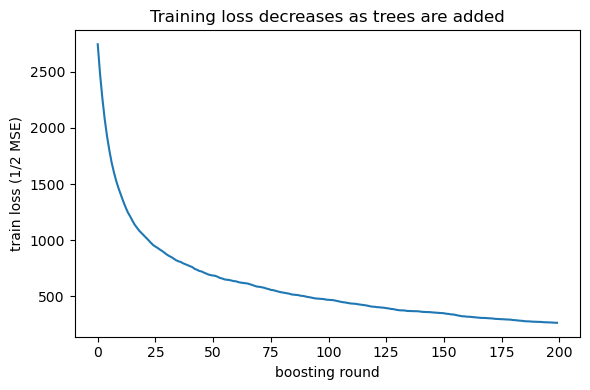

In [5]:
X, y = load_diabetes(return_X_y=True)
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=0)

reg = XGBoost(n_estimators=200, learning_rate=0.1, max_depth=3,
              reg_lambda=1.0, gamma=0.0, min_child_weight=1.0,
              objective="reg:squarederror")
reg.fit(Xtr, ytr, verbose=True)

pred = reg.predict(Xte)
rmse = mean_squared_error(yte, pred) ** 0.5
print(f"\nScratch XGBoost test RMSE: {rmse:.3f}")

plt.figure(figsize=(6, 4))
plt.plot(reg.history)
plt.xlabel("boosting round"); plt.ylabel("train loss (1/2 MSE)")
plt.title("Training loss decreases as trees are added")
plt.tight_layout(); plt.show()

## 9b. Demo: binary classification on Breast Cancer

Same model class, only the objective changes — the tree code is untouched because it
only ever sees $g$ and $h$. We report accuracy and AUC.

In [6]:
Xc, yc = load_breast_cancer(return_X_y=True)
Xtr, Xte, ytr, yte = train_test_split(Xc, yc, test_size=0.2,
                                      random_state=0, stratify=yc)

clf = XGBoost(n_estimators=150, learning_rate=0.2, max_depth=3,
              reg_lambda=1.0, gamma=0.0, min_child_weight=1.0,
              objective="binary:logistic")
clf.fit(Xtr, ytr, verbose=True)

proba = clf.predict(Xte)
labels = clf.predict_label(Xte)
print(f"\nScratch XGBoost  accuracy: {accuracy_score(yte, labels):.4f}")
print(f"Scratch XGBoost  ROC AUC : {roc_auc_score(yte, proba):.4f}")

round    0   train loss = 0.50551


round   15   train loss = 0.04852


round   30   train loss = 0.01742
round   45   train loss = 0.01102


round   60   train loss = 0.00862
round   75   train loss = 0.00742


round   90   train loss = 0.00687
round  105   train loss = 0.00643
round  120   train loss = 0.00606


round  135   train loss = 0.00578

Scratch XGBoost  accuracy: 0.9561
Scratch XGBoost  ROC AUC : 0.9888


## 9c. Sanity check against the reference `xgboost`

If our math is right, the official library with matching hyper-parameters should land
in the same ballpark. (Exact equality is not expected — the real library uses
weighted quantile sketching for splits, column/row subsampling, and other tricks we
left out for clarity.) This cell is skipped automatically if `xgboost` is not
installed.

In [7]:
try:
    import xgboost as xgb

    ref = xgb.XGBClassifier(
        n_estimators=150, learning_rate=0.2, max_depth=3,
        reg_lambda=1.0, gamma=0.0, min_child_weight=1.0,
        objective="binary:logistic", eval_metric="logloss",
        tree_method="exact", base_score=0.5,
    )
    ref.fit(Xtr, ytr)
    ref_proba = ref.predict_proba(Xte)[:, 1]
    ref_labels = (ref_proba >= 0.5).astype(int)

    print("                 accuracy    AUC")
    print(f"scratch  XGBoost   {accuracy_score(yte, labels):.4f}    {roc_auc_score(yte, proba):.4f}")
    print(f"official XGBoost   {accuracy_score(yte, ref_labels):.4f}    {roc_auc_score(yte, ref_proba):.4f}")
except ImportError:
    print("xgboost not installed - skipping reference comparison.")
    print("Install with:  pip install xgboost")

xgboost not installed - skipping reference comparison.
Install with:  pip install xgboost


## Summary

We derived and implemented XGBoost end to end:

| Step | Math | Where in code |
|------|------|---------------|
| 1 | Regularized objective $\sum l + \sum \Omega$ | `XGBoost` design, `reg_lambda`, `gamma` |
| 2 | Additive training $\hat{y}^{(t)}=\hat{y}^{(t-1)}+f_t$ | `XGBoost.fit` loop |
| 3 | 2nd-order Taylor $\to g_i,h_i$ | `*.gradient`, `*.hessian` |
| 4 | $w_j^*=-G_j/(H_j+\lambda)$ | `XGBoostTree._leaf_weight` |
| 5 | split `Gain` | `XGBoostTree._gain`, `_best_split` |
| 6 | loss derivatives | `SquaredErrorLoss`, `LogisticLoss` |
| 8 | shrinkage $\eta$ | `learning_rate` update |

The two ideas that make XGBoost "extreme": (1) the **second-order Taylor expansion**
compresses any loss into a per-example $(g_i, h_i)$, so the tree learner is fully
loss-agnostic; and (2) **regularization is baked into the optimization** — $\lambda$
shrinks leaf weights and $\gamma$ prunes leaves directly through the gain formula,
rather than being bolted on afterward.

Natural extensions left as exercises: column/row subsampling, the weighted quantile
sketch for approximate split finding, sparsity-aware default directions for missing
values, and multi-class via one-vs-all softmax.